# Crypto Perps Funding: Feature Engineering

A perpetual future has no expiry, so the only thing tying it to spot is a payment between its
holders. That payment is the funding rate, and its sign says who pays whom: where the rate is
positive the holders of long positions pay the holders of short ones, and where it is negative
the payment runs the other way. What drives the sign is mostly how far the contract trades from
spot, but not only that - the exchange adds a small interest term, so a contract trading a
little below spot can still leave longs paying. It normally settles every eight hours, though
the exchange can shorten an individual contract's interval, and Section B counts how often that
happened here.

What the exchange computes the rate from is the **premium index**, its own published measure of
how far the contract sits from the spot price it tracks. Two things carry that name and this
notebook uses only one of them: the funding formula takes a time-weighted average of the premium
index over the interval ending at the settlement, and adds an interest term and a cap, while the
features below read `premium_index_close`, the index's value at the close of each eight-hour
bar. Every feature meant to rank one contract against another is a transformation of that series
and of the settled rate; a handful of others describe the conditions a ranking is formed in and
come from elsewhere - the contract's own price for its volatility, the timestamp for which of
the three daily settlements a row belongs to, and the configuration for its fee tier. The
question each feature has to answer first is not whether it predicts but whether it is knowable:
at a settlement, which observations have already been published, and what does the feature make
of them?

## Learning objectives

- State a feature's timing contract - its lookback and its information lag - before writing the
  code that computes it
- Restamp a provider's bars from the time each one opened to the time it became knowable, and
  see why every later shift, join and window inherits that single decision
- Show that withholding later settlements leaves every feature value unchanged, which separates
  a trailing statistic from one fitted over the whole sample
- Read a feature set for scale, dispersion, redundancy and decay before any model sees it

## Book reference, prerequisites and artifacts

Chapter 8. Reads eight-hourly perpetual bars and the premium index via `load_crypto_perps()`,
the official Binance settlement series via `load_funding_rates()`, and `config/setup.yaml`.
Writes `features/financial.parquet` with a `.digest.json` sidecar, read by
[`04_model_based_features`](04_model_based_features.ipynb), which fits regime and volatility
features on top of it fold by fold, and by [`05_evaluation`](05_evaluation.ipynb), which tests
whether any of it predicts. [`02_labels`](02_labels.ipynb) stamps its forward returns the same
way Section B stamps these features, so a feature row and a label row carrying one timestamp
describe one decision; nothing here reads a label.

In [1]:
"""Crypto Perps Funding: Feature Engineering."""

import warnings
from datetime import UTC, datetime, timedelta

import numpy as np
import polars as pl
import yaml
from IPython.display import display
from ml4t.engineer.features.ml import percentile_rank_features

from case_studies.crypto_perps_funding.funding_data import load_funding_rates
from case_studies.utils.artifact_digest import value_digest, write_artifact
from case_studies.utils.feature_engineering import (
    EPS,
    assert_values_agree,
    assign_families,
    cross_sectional_percentile,
    families_from_config,
    family_coverage,
    plot_coverage_through_time,
    plot_cross_sectional_dispersion,
    plot_feature_distributions,
    plot_persistence,
    plot_redundancy_clusters,
    plot_timing_contract,
    register_frame,
    rolling_zscore,
    trailing_volatility,
    warmup_audit,
)
from data import load_crypto_perps
from utils.paths import get_case_study_dir

warnings.filterwarnings("ignore")

CASE_DIR = get_case_study_dir("crypto_perps_funding")
FEATURES_DIR = CASE_DIR / "features"

`START_DATE` is unset, so the loader below returns each perpetual's full history. Readers can
override it through Papermill to run the notebook over a shorter window. There is no matching
cap on the number of symbols: the within-settlement features rank each perpetual against the
others trading at the same moment, and a truncated universe changes every one of those values.

In [2]:
START_DATE = None

## Configuration

Every window, clip bound, the fee tier, the ranked column and the holdout boundary are declared
in `config/setup.yaml` and bound here. A window typed into a cell is a second copy of a number
the warmup audit and the timing figure both have to agree with, and the two drift apart the first
time either is edited. Each window map reads `suffix: bars`: the emitted names carry hours in
some families and days in others, and that naming is a schema every later stage reads.

In [3]:
setup = yaml.safe_load((CASE_DIR / "config" / "setup.yaml").read_text())
features_cfg = setup["features"]
FAMILIES = families_from_config(setup)
W = features_cfg["windows"]
CLIP = features_cfg["clip"]
MAJORS = set(features_cfg["majors"])
RANKED = features_cfg["ranked"]
REDUNDANCY_CUT = features_cfg["redundancy_cut"]
BAR_HOURS = features_cfg["bar_hours"]
BARS_PER_YEAR = setup["evaluation"]["periods_per_year"] * 24 / BAR_HOURS
HOLDOUT_START = datetime.fromisoformat(setup["evaluation"]["holdout_start"]).replace(tzinfo=UTC)
WINDOW_END = datetime.fromisoformat(setup["evaluation"]["holdout_end"]).replace(
    tzinfo=UTC
) + timedelta(days=1)

print(f"{len(FAMILIES)} declared families, {BAR_HOURS}-hour settlement bars")
print(f"Holdout opens {HOLDOUT_START.date()}; Section D rebuilds the panel without it")

6 declared families, 8-hour settlement bars
Holdout opens 2024-01-01; Section D rebuilds the panel without it


## A. What the thesis says should carry information

The hypothesis is cross-sectional and it is about crowding. When a perpetual trades above the
spot index, longs pay shorts to keep the contract open, and the size of that payment measures
how one-sided the positioning is. A perpetual whose holders are paying most is expected to give
ground relative to the rest of the universe over the following settlements. Three things follow.

The **signal families** are funding and the premium it is computed from, entered in four
representations rather than one, because a raw premium is comparable neither across symbols nor
across regimes: the level, its z-score against its own history, its percentile within the
settlement, and the speed at which it decays back. Which of those the effect lives in is a
question `05_evaluation` asks.

The **conditioning** is regime. Crowding unwinds differently in a quiet week than in a
liquidation cascade - a stretch where falling prices force leveraged positions to be closed,
which pushes prices down further and forces more of them - so the matrix also carries the
dispersion of the premium and of the price, the
short-over-long volatility ratios, a sustained-premium indicator and the settlement slot. These
rank nothing against each other; they say which environment a ranking is being formed in, which
is what the register's `role` column records and no assertion can recover from the values.

The **failure modes** are stated with the families rather than discovered later: the exchange
caps the funding rate at a fixed bound, so the rate stops moving in exactly the regimes that
matter most, and momentum and mean reversion read one series with opposite signs, so a model
given both may find they cancel. Every lag in the register is zero, and Section B is where that
is earned.

In [4]:
register_frame(FAMILIES).select(["family", "role", "inputs", "lookback (bars)", "lag (bars)"])

family,role,inputs,lookback (bars),lag (bars)
str,str,str,i64,i64
"""carry""","""signal""","""official funding settlements, …",43,0
"""mean_reversion""","""signal""","""premium index close""",90,0
"""momentum""","""signal""","""premium index close""",90,0
"""volatility""","""state""","""premium index close, perpetual…",43,0
"""cross_sectional""","""state""","""premium index close, official …",1,0
"""regime""","""state""","""premium index close, symbol, d…",10,0


## B. Inputs and their observability

Binance stamps each kline with the time its bar **opened**, so a row stamped midnight reports a
close, a volume and a premium index that nobody knows until eight hours later. The series is
advanced by one bar length before anything is joined, shifted or filtered, and the resulting
`timestamp` is the boundary at which the completed bar is available.
[`02_labels`](02_labels.ipynb) advances it the same way, so a feature row and a label row
carrying one timestamp describe one decision.

The official settlement series needs no such shift. Its `calc_time` is the settlement instant
itself, and the rate is the time-weighted premium over the interval ending there plus the
interest component and the exchange clamp - so the newest input to `funding_rate` at a
timestamp is dated at that timestamp. The last two lines below are what would catch that being
wrong: a rate determined by the interval that ends at its own stamp tracks the return over that
interval, and a rate stamped a bar early would instead track the one that follows it.

One feature is summed on the funding series' own clock rather than as a fixed number of rows on
the eight-hour panel. Binance can shorten a contract's settlement interval to two or four hours
when the premium runs far from its band, and during such a stretch seven days hold more than
twenty-one settlements. A fixed twenty-one-row sum would then omit real cash flows, so the
seven-day total is taken over a seven-day *time* window and counts whatever settlements fall in
it. The count of shortened intervals printed below is how much of the sample this affects.

In [5]:
available_at = (pl.col("timestamp") + pl.duration(hours=BAR_HOURS)).alias("timestamp")
prices = (
    load_crypto_perps(frequency=f"{BAR_HOURS}h", start_date=START_DATE)
    .with_columns(available_at)
    .filter(pl.col("timestamp") < WINDOW_END)
    .sort(["symbol", "timestamp"])
)
funding = load_funding_rates(symbols=prices["symbol"].unique().to_list())
required = {"open", "high", "low", "close", "volume", "premium_index_close"}
assert not required - set(prices.columns), (
    f"loader missing {sorted(required - set(prices.columns))}"
)

cashflow_label, cashflow_days = next(iter(W["funding_cashflow"].items()))
cashflows = (
    funding.with_columns(pl.col("funding_rate").clip(lower_bound=0.0).alias("_paid"))
    .rolling(
        index_column="timestamp", period=f"{cashflow_days}d", group_by="symbol", closed="right"
    )
    .agg(pl.col("_paid").sum().alias(f"cum_positive_funding_{cashflow_label}"))
)
panel = prices.join(
    funding.select("timestamp", "symbol", "funding_rate"), on=["timestamp", "symbol"], how="left"
).join(cashflows, on=["timestamp", "symbol"], how="left")
observability = panel.sort(["symbol", "timestamp"]).select(
    pl.corr(pl.col("funding_rate"), pl.col("close").log().diff().over("symbol")).alias("backward"),
    pl.corr(
        pl.col("funding_rate"), pl.col("close").log().diff().over("symbol").shift(-1).over("symbol")
    ).alias("forward"),
)
print(f"{len(panel):,} settlement bars over {panel['symbol'].n_unique()} perpetuals")
print(f"{panel['funding_rate'].is_not_null().mean():.4%} of them carry an official settlement")
print(f"{funding.filter(pl.col('funding_interval_hours') != BAR_HOURS).height} shortened intervals")
print(f"funding against the interval it is computed from: {observability['backward'][0]:+.4f}")
print(f"funding against the interval that follows it:     {observability['forward'][0]:+.4f}")

108,298 settlement bars over 19 perpetuals
99.6833% of them carry an official settlement
101 shortened intervals
funding against the interval it is computed from: +0.0586
funding against the interval that follows it:     -0.0005


### What is actually in the panel

The universe is a fixed list of nineteen perpetuals, and it is unbalanced: a contract enters the
panel when Binance lists it and nothing is backfilled before that date. The table below carries
the three properties of it that later sections here depend on, and
[`01_feasibility_analysis`](01_feasibility_analysis.ipynb) describes the universe in full.

**First settlement** is the earliest bar a contract contributes, and the spread of those dates is
what makes the panel unbalanced - which is why C.5 normalizes its cross-sectional position by the
number of contracts quoting rather than by a fixed nineteen. **Missing premium** counts the bars
whose premium index the exchange did not publish; those are the gaps whose cost Section E
measures, and they are not spread evenly across contracts. **Fee tier** is the `cost_tier_alt`
feature, and it records an assumption rather than a measurement: the configuration assumes the
five largest contracts can be traded passively, at the two-basis-point maker fee, and that the
rest have to take liquidity at four. It reaches the matrix only as something a model can
condition on. It does not set what a trade costs anywhere downstream - the backtest configuration
charges one commission rate on every contract - so a difference between the two groups in the
reported results comes from the model using the column, never from one group being charged more.

In [6]:
universe = (
    panel.group_by("symbol")
    .agg(
        pl.col("timestamp").min().dt.date().alias("first settlement"),
        pl.len().alias("bars"),
        pl.col("premium_index_close").is_null().sum().alias("missing premium"),
    )
    .with_columns(
        pl.when(pl.col("symbol").is_in(list(MAJORS)))
        .then(pl.lit("maker"))
        .otherwise(pl.lit("taker"))
        .alias("fee tier")
    )
    .sort(["first settlement", "symbol"])
)
with pl.Config(tbl_rows=universe.height, tbl_cols=universe.width):
    display(universe)

symbol,first settlement,bars,missing premium,fee tier
str,date,u32,u32,str
"""BTCUSDT""",2020-01-01,6575,21,"""maker"""
"""ETHUSDT""",2020-01-01,6575,21,"""maker"""
"""XRPUSDT""",2020-01-06,6544,18,"""maker"""
"""LINKUSDT""",2020-01-17,6526,21,"""taker"""
"""ADAUSDT""",2020-01-31,6484,21,"""taker"""
"""ATOMUSDT""",2020-02-07,6463,18,"""taker"""
"""BNBUSDT""",2020-02-10,6454,21,"""maker"""
"""COMPUSDT""",2020-06-30,6031,21,"""taker"""
"""DOGEUSDT""",2020-07-10,6001,21,"""taker"""


## C. Feature construction, one subsection per family

### C.1 Carry: the funding rate and the premium it is computed from

The z-score is the shared trailing primitive: mean and dispersion over the row's own history,
divided by a dispersion held off zero by `EPS`, a small floor the case-study helpers apply so a
window in which the series never moved returns a bounded number instead of dividing by zero. It
does not rescue a window that has no dispersion to compute - one still filling, or one spanning
a missing observation, is null before the floor and stays null after it. Its clip is not a guard
but a decision the configuration declares, because a settlement-day outlier otherwise sets the
scale a model reads.

The half-life is local, since no library call covers it. It is the time a deviation in the
settled rate takes to decay by half, read off a rolling AR(1) coefficient. That coefficient is
the slope of a regression of the rate on its own previous value,
$\rho = \mathrm{Cov}(r_t, r_{t-1}) / \mathrm{Var}(r_{t-1})$ - a slope, not a correlation, which
would divide by both standard deviations instead. A series that decays geometrically at rate
$\rho$ halves in $-\log 2 / \log|\rho|$ periods. Both moments are taken over trailing windows so
nothing is estimated across the sample, and the result is clipped where the coefficient
approaches one and the implied half-life diverges.

Two choices in it are worth making explicit, because a reader building the same feature on their
own data faces both. The first is that its denominator is guarded on being **positive** rather
than floored at `EPS`. A floor is a guard only while it sits far below the quantity it protects,
and that is a property of the units, not of the code: the denominator here is the variance of a
rate whose typical magnitude is a basis point, so squaring it lands the whole distribution near
the floor. The measurement below the definitions locates the floor against that distribution.
Where it falls inside, flooring stops guarding and starts setting the answer, and a positivity
test is what the guard should have been.

The second is that a coefficient which cannot be estimated has no single sensible default, so
each case is named rather than swept into one `otherwise`. Before the trailing moments exist
there is no coefficient and the column is null. A coefficient of exactly zero is a series that
has **already** reverted, so its half-life is the configured floor; the tempting alternative, to
hand those rows the window length, reports the least persistent rows as the slowest to decay.

In [7]:
def carry_features(df: pl.DataFrame) -> pl.DataFrame:
    """Funding and premium level, dispersion-normalized, and the reversion speed."""
    z = CLIP["zscore"]
    df = df.with_columns(
        [
            rolling_zscore("premium_index_close", bars, "symbol")
            .clip(-z, z)
            .alias(f"premium_zscore_{label}")
            for label, bars in W["premium_zscore"].items()
        ]
        + [
            rolling_zscore("funding_rate", bars, "symbol")
            .clip(-z, z)
            .alias(f"funding_rate_zscore_{label}")
            for label, bars in W["funding_zscore"].items()
        ]
        + [pl.col("premium_index_close").alias("premium_level")]
    )
    for label, bars in W["funding_half_life"].items():
        df = funding_moments(df, bars).with_columns(half_life().alias(f"funding_half_life_{label}"))
    return df.drop("_cov", "_var")


def funding_moments(df: pl.DataFrame, bars: int) -> pl.DataFrame:
    """Trailing covariance of the settlement series with its own lag, and the lag's variance."""
    lagged = pl.col("funding_rate").shift(1).over("symbol")
    return df.with_columns(
        (
            (pl.col("funding_rate") * lagged).rolling_mean(bars).over("symbol")
            - pl.col("funding_rate").rolling_mean(bars).over("symbol")
            * lagged.rolling_mean(bars).over("symbol")
        ).alias("_cov"),
        lagged.rolling_var(bars, ddof=0).over("symbol").alias("_var"),
    )


def half_life() -> pl.Expr:
    """Half-life implied by the trailing AR(1) coefficient of the settlement series."""
    floor, ceiling = CLIP["half_life"]
    rho = (
        pl.when(pl.col("_var") > 0)
        .then(pl.col("_cov") / pl.col("_var"))
        .clip(-CLIP["ar1"], CLIP["ar1"])
    )
    return (
        pl.when(rho.is_null())
        .then(None)
        .when(rho == 0)
        .then(pl.lit(floor))
        .otherwise(-np.log(2) / rho.abs().log())
        .clip(floor, ceiling)
    )

Whether `EPS` would work as the denominator's floor is a question about this panel's units, and
it is cheaper to answer than to reason about. The trailing variance is compared against the floor
directly: if the floor sits in the body of that distribution rather than below it, a floored
denominator returns the floor on those rows and the half-life they report is a property of the
constant, not of the rate. The same comparison is worth running on any series before reusing a
shared epsilon on it: the same quantity expressed in percent and in basis points differs by four
orders of magnitude once squared, and only one of the two clears a fixed floor.

In [8]:
_bars = W["funding_half_life"]["14d"]
_var = funding_moments(panel.sort(["symbol", "timestamp"]), _bars)["_var"]
_estimable = _var.drop_nulls()
print(f"denominator floor EPS:                        {EPS:.0e}")
print(f"median trailing variance of the settled rate: {_estimable.median():.2e}")
print(f"share of estimable rows below that floor:     {(_estimable < EPS).mean():.2%}")
print(f"share the positivity test rejects instead:    {(_estimable <= 0).mean():.2%}")

denominator floor EPS:                        1e-08
median trailing variance of the settled rate: 7.06e-09
share of estimable rows below that floor:     57.46%
share the positivity test rejects instead:    0.97%


### C.2 Mean reversion: where the premium sits in its own recent range

The rolling percentile is `ml4t.engineer.features.ml.percentile_rank_features`, which ranks the
current premium against the window that ends at it. It is a *time-series* percentile, not a
cross-sectional one - it answers "high for this symbol lately", where C.5 answers "high against
what everyone else is paying now" - and the two are separate features because they disagree
whenever the whole universe moves together.

In [9]:
def mean_reversion_features(df: pl.DataFrame) -> pl.DataFrame:
    """Deviation from a trailing mean, position in the trailing distribution, sign persistence."""
    windows = W["premium_quantile"]
    ranks = percentile_rank_features(RANKED, windows=list(windows.values()))
    return df.with_columns(
        [
            (pl.col(RANKED) - pl.col(RANKED).rolling_mean(bars).over("symbol")).alias(
                f"premium_dev_mean_{label}"
            )
            for label, bars in W["premium_dev_mean"].items()
        ]
        + [
            ranks[f"rank_{bars}"].over("symbol").alias(f"premium_quantile_pos_{label}")
            for label, bars in windows.items()
        ]
        + [
            (pl.col(RANKED) > 0)
            .cast(pl.Float64)
            .rolling_mean(bars)
            .over("symbol")
            .alias(f"premium_persistence_{label}")
            for label, bars in W["premium_persistence"].items()
        ]
    )

### C.3 Momentum: how the premium got where it is

Six trailing differences, and two differences between them. The acceleration terms compare a
short window against a longer one, so a premium that widened last settlement but has been
narrowing all week reads differently from one doing both.

In [10]:
def momentum_features(df: pl.DataFrame) -> pl.DataFrame:
    """Premium differences at six horizons, the funding-rate change, and two accelerations."""
    horizons = W["premium_momentum"]
    df = df.with_columns(
        [
            (pl.col(RANKED) - pl.col(RANKED).shift(bars).over("symbol")).alias(
                f"premium_change_{label}"
            )
            for label, bars in horizons.items()
        ]
        + [
            (pl.col("funding_rate") - pl.col("funding_rate").shift(bars).over("symbol")).alias(
                f"funding_rate_change_{label}"
            )
            for label, bars in W["funding_change"].items()
        ]
    )
    short, medium, long = list(horizons)[1:4]
    return df.with_columns(
        (pl.col(f"premium_change_{short}") - pl.col(f"premium_change_{medium}")).alias(
            "premium_accel_short"
        ),
        (pl.col(f"premium_change_{medium}") - pl.col(f"premium_change_{long}")).alias(
            "premium_accel_medium"
        ),
    )

### C.4 Volatility: two dispersions that are not the same quantity

Price volatility is the shared trailing primitive on the perpetual's log return, annualized at
the case study's own bar count so it is on the scale a volatility is read on and comparable with
the other eight case studies. Premium volatility stays local and unannualized: the premium index
is a rate in its own units rather than a return, so a root-time factor would put a number on it
that does not mean what an annualized volatility means.

In [11]:
def volatility_features(df: pl.DataFrame) -> pl.DataFrame:
    """Trailing dispersion of the premium and of the price, plus short-over-long ratios."""
    df = df.with_columns(
        [
            pl.col("_premium_change").rolling_std(bars).over("symbol").alias(f"premium_vol_{label}")
            for label, bars in W["premium_volatility"].items()
        ]
        + [
            trailing_volatility(
                "_log_return", bars, "symbol", periods_per_year=BARS_PER_YEAR
            ).alias(f"price_vol_{label}")
            for label, bars in W["price_volatility"].items()
        ]
    )
    short, medium, long, longest = list(W["premium_volatility"])
    cap = CLIP["vol_ratio"]
    return df.with_columns(
        (pl.col(f"premium_vol_{short}") / pl.col(f"premium_vol_{long}").clip(lower_bound=EPS))
        .clip(upper_bound=cap)
        .alias("vol_ratio_short"),
        (pl.col(f"premium_vol_{medium}") / pl.col(f"premium_vol_{longest}").clip(lower_bound=EPS))
        .clip(upper_bound=cap)
        .alias("vol_ratio_medium"),
    )

### C.5 Cross-sectional position within one settlement

Three statistics taken with `.over("timestamp")`, so each reads every symbol trading at that
settlement and no other date. The percentile uses the shared primitive, whose denominator is the
count plus one: that keeps the widest-premium perpetual off the boundary, so the column is a
position in the cross-section rather than a rank divided by its own maximum. That distinction is
what makes it comparable across dates, and the table above is why it matters here - the panel is
unbalanced, so an early settlement ranks a handful of contracts and a late one ranks nineteen,
and a rank divided by its own maximum would put the widest premium at the top of the scale in
both, whether it beat two contracts or eighteen.

In [12]:
def cross_sectional_features(df: pl.DataFrame) -> pl.DataFrame:
    """Distance from the settlement's median, its z-score, and the dispersion of funding paid."""
    return df.with_columns(
        (pl.col(RANKED) - pl.col(RANKED).median().over("timestamp")).alias("premium_vs_median"),
        (
            (pl.col(RANKED) - pl.col(RANKED).mean().over("timestamp"))
            / pl.col(RANKED).std().over("timestamp").clip(lower_bound=EPS)
        )
        .clip(-CLIP["zscore"], CLIP["zscore"])
        .alias("premium_xs_zscore"),
        pl.col("funding_rate").std().over("timestamp").alias("xs_funding_dispersion"),
    )

### C.6 Regime and calendar

The oscillator is the relative strength index: the share of recent movement that was upward,
mapped onto a nought-to-hundred scale, so a premium that has only widened reads near a hundred
and one that has only narrowed reads near nought. The library call
`ml4t.engineer.features.momentum.rsi` is the standard form, and it is deliberately not used here.
It carries Wilder's smoothing, a recursive average in which each value is computed from the one
before it, and a recursion has no way to skip a missing observation: the premium index has gaps,
and the first one a contract meets propagates into every value after it. An average over a fixed
window has a defined answer in both cases - nothing while the window spans the gap, and a usable
number once the gap has passed out of it. The two are different statistics rather than two
implementations of one, which is why this column is not called a Wilder RSI.

The settlement slot and the fee tier are the two columns with no lookback at all: the slot is a
property of the timestamp, and the tier is a fixed list the configuration declares.

In [13]:
def regime_features(df: pl.DataFrame) -> pl.DataFrame:
    """Sustained-premium indicator, bounded oscillators, settlement slot and fee tier."""
    return df.with_columns(
        [
            pl.when(pl.col(RANKED) > 0)
            .then(1.0)
            .otherwise(-1.0)
            .rolling_mean(bars)
            .over("symbol")
            .alias(f"premium_regime_{label}")
            for label, bars in W["premium_regime"].items()
        ]
        + [
            (
                100
                - 100
                / (
                    1
                    + pl.col("_premium_change")
                    .clip(lower_bound=0)
                    .rolling_mean(bars)
                    .over("symbol")
                    / (-pl.col("_premium_change"))
                    .clip(lower_bound=0)
                    .rolling_mean(bars)
                    .over("symbol")
                    .clip(lower_bound=EPS)
                )
            ).alias(f"premium_rsi_{label}")
            for label, bars in W["premium_rsi"].items()
        ]
        + [
            (pl.col("timestamp").dt.hour() // BAR_HOURS).cast(pl.Int32).alias("funding_session"),
            pl.when(pl.col("symbol").is_in(list(MAJORS)))
            .then(0)
            .otherwise(1)
            .cast(pl.Int32)
            .alias("cost_tier_alt"),
        ]
    )

### C.7 The order the three steps run in

Everything above is computed from one perpetual's own history, so the order those steps run in
does not matter. The four within-settlement statistics are different, and they put the null
policy **between** the two groups rather than after both. A percentile, a median and a dispersion
are properties of the cross-section they are taken over, so a perpetual the matrix will not carry
must not be in that cross-section: leaving it in moves the number written for every perpetual
that is. Gate first, then take the cross-section over exactly the rows that survived.

That ordering decides which cross-section is read. It does not yet establish that there is one.
The z-score and the dispersion are both standard deviations over the settlement, and a standard
deviation is undefined at a single observation, so a settlement the gate reduces to one perpetual
has no value to write for either. The gate therefore takes a second clause - a settlement reaches
the matrix only if at least `MIN_CROSS_SECTION` perpetuals survive it - and the median and the
percentile go with them, because a position in a cross-section of one is not a position at all.

In [14]:
def per_symbol_features(df: pl.DataFrame) -> pl.DataFrame:
    """Everything computed from one perpetual's own history, before any gate."""
    return (
        df.sort(["symbol", "timestamp"])
        .with_columns(
            (pl.col(RANKED) - pl.col(RANKED).shift(1).over("symbol")).alias("_premium_change"),
            pl.col("close").log().diff().over("symbol").alias("_log_return"),
        )
        .pipe(carry_features)
        .pipe(mean_reversion_features)
        .pipe(momentum_features)
        .pipe(volatility_features)
        .pipe(regime_features)
    )


# Two, because that is the smallest cross-section a standard deviation is defined on. This is not
# a tuning choice and it is not declared in the configuration for that reason.
MIN_CROSS_SECTION = 2


def build_features(df: pl.DataFrame) -> pl.DataFrame:
    """The whole construction, as one function Section D can re-run on a shorter panel."""
    trailing = per_symbol_features(df)
    eligible = trailing.drop_nulls(subset=[c for c in SYMBOL_COLS if c in trailing.columns])
    contested = eligible.filter(pl.len().over("timestamp") >= MIN_CROSS_SECTION)
    return contested.pipe(cross_sectional_features).with_columns(
        cross_sectional_percentile(RANKED, "timestamp").alias("premium_rank")
    )


# The two carry columns are joined in Section B and shipped as features, so they are added back
# to the input frame's own columns before the difference; taking the difference alone drops them.
CARRIED = {"funding_rate", f"cum_positive_funding_{cashflow_label}"}
EXCLUDED = (set(panel.columns) | {"_premium_change", "_log_return"}) - CARRIED
XS_COLS = ["premium_vs_median", "premium_xs_zscore", "xs_funding_dispersion", "premium_rank"]

trailing = per_symbol_features(panel)
SYMBOL_COLS = sorted(c for c in trailing.columns if c not in EXCLUDED)
built = build_features(panel)
feature_cols = sorted(assign_families(SYMBOL_COLS + XS_COLS, FAMILIES))
print(f"{len(trailing):,} bars carrying {len(SYMBOL_COLS)} per-symbol features")
print(f"{len(built):,} pass the gate and carry the {len(XS_COLS)} within-settlement features")

108,298 bars carrying 35 per-symbol features
99,877 pass the gate and carry the 4 within-settlement features


## D. The timing contract

### D.1 What each construction reads

Three kinds of operation appear above. A **rolling** window ends at its own row and reads a fixed
number of settlements backward, always `.over("symbol")`, so a shift means "the previous
settlement for this perpetual" and never "the previous row in the file". A **cross-sectional**
statistic - the three in C.5 and the percentile - is taken with `.over("timestamp")`, so it reads
every perpetual at that settlement and no other date. A **time-based rolling** aggregate builds
the seven-day cash flow on the settlement series' own clock, which is what lets it span an
interval the exchange shortened. None of the three reaches forward, and D.2 and D.3 establish it
rather than asserting it. F4, below the coverage figure, draws the same contract as a picture.

### D.2 Warmup

A trailing window cannot produce a value until it has enough settlements to fill, so every family
has a leading stretch of nulls as long as its lookback. The audit checks that length rather than
describing it: a column holding a value before its window could have filled is reading bars that
do not exist, and that is what it raises on. It is worth running even where the windows look
obvious, because the failure it catches is not a wrong window but a branch that returns a
fallback instead of a null - a column that reports a value from the first bar of the sample has
a default somewhere, and a default is indistinguishable from an estimate once it is in a model.

It runs on the panel before the gate, because the gate drops the warmup stretch it measures.

In [15]:
warmup_audit(
    trailing,
    {
        "premium_change_720h": W["premium_momentum"]["720h"],
        "premium_quantile_pos_30d": W["premium_quantile"]["30d"],
        "premium_zscore_14d": W["premium_zscore"]["14d"],
        "funding_rate_zscore_14d": W["funding_zscore"]["14d"],
        "funding_half_life_14d": W["funding_half_life"]["14d"],
        "price_vol_14d": W["price_volatility"]["14d"],
        "premium_vol_336h": W["premium_volatility"]["336h"],
        "vol_ratio_medium": W["premium_volatility"]["336h"],
        "premium_regime_72h": W["premium_regime"]["72h"],
    },
    entity="symbol",
)

column,declared warmup (bars),first populated bar,populated
str,i64,i64,bool
"""premium_change_720h""",90,91,true
"""premium_quantile_pos_30d""",90,90,true
"""premium_zscore_14d""",42,42,true
"""funding_rate_zscore_14d""",42,42,true
"""funding_half_life_14d""",42,43,true
"""price_vol_14d""",42,43,true
"""premium_vol_336h""",42,43,true
"""vol_ratio_medium""",42,43,true
"""premium_regime_72h""",9,9,true


### D.3 Withholding the holdout changes nothing

Trailing and within-settlement statistics share a property worth checking directly: recomputed on
a panel that stops before the holdout, they reproduce the same values on the rows the two panels
share. A parameter fitted over a whole column - a winsorization bound, a scaler, an encoder -
does not, because truncating the column moves the parameter and with it every row it was applied
to. Building the panel twice tests the whole construction at once, every emitted column rather
than a sample, and does not depend on anyone having flagged the transform that fits. A value on
one side against a null on the other counts as a difference, which is the form of the failure a
null-skipping comparison hides.

In [16]:
seal = assert_values_agree(
    built.filter(pl.col("timestamp") < HOLDOUT_START),
    build_features(panel.filter(pl.col("timestamp") < HOLDOUT_START)),
    columns=feature_cols,
    keys=["timestamp", "symbol"],
)
seal.filter(pl.col("column").is_in(["premium_rank", "premium_xs_zscore", "funding_half_life_14d"]))

column,rows compared,null only on one side,max abs difference
str,i64,i64,f64
"""funding_half_life_14d""",59002,0,0.0
"""premium_rank""",59002,0,0.0
"""premium_xs_zscore""",59002,0,0.0


## E. Matrix assembly and coverage

The panel key is `symbol` + `timestamp`. The raw open, high, low, close, volume and premium index
are excluded: they are the inputs the features are made of, and a model handed the
contemporaneous close beside a label derived from the same price would be reading its own answer.
So are the two intermediates the construction passes between subsections. `premium_level` is the
deliberate exception, the premium index under a name that says it is shipped as a signal.

One null policy is applied once, and C.7 is where: a row reaches the matrix only when every
per-symbol feature on it is observed and its settlement retains the two perpetuals a
within-settlement statistic needs, and those statistics are then taken over exactly the rows that
survived. Dropping a row is the strictest of the available policies and it is chosen deliberately:
a model handed a null has to be told what to do with it, the successor stages include sequence
models that have no answer, and the alternative - filling the gap with a carried-forward or
imputed value - invents an observation the exchange never published. The assertion below is what
makes the resulting matrix complete by fact rather than by intention.

What that buys is that every row emitted is complete on every feature. What it does not buy is
that the rows are consecutive: dropping a row leaves a hole in the settlement sequence. A model
reading this matrix row by row - and the sequence models downstream do - forms a window by
counting rows, so a window of sixty rows that spans a hole covers more than sixty settlements of
elapsed time. That is a property of the emitted panel, and the timestamp column is what a
consumer would have to read to detect it.

That policy has a price, and it is worth knowing where the price is paid before reading the
coverage figure. The perpetual close and its volume are complete. The other two inputs are not:
the premium index has scattered gaps, and a small share of bars carry no official settlement,
both of which Section B counts. One missing observation of either empties every window that
spans it. How many rows that costs depends on
the shape of the statistic: a rolling window of ninety settlements is spanned by ninety
successive rows, so one gap removes ninety, while a difference against the value ninety
settlements back reads only two rows and removes two. Gaps close together cost less than gaps
far apart, because their invalidated stretches overlap - two gaps k settlements apart, with k
below the window length, remove the window length plus k rows rather than twice the window - but
they never cost nothing extra. And because a row is kept only when every feature on it is
observed, it is the longest window in the matrix that sets the reach of each gap.

The cell below splits the discarded rows between those gaps and the warmup, and it does so by
measurement rather than by reasoning about which input feeds which feature. Each contract's
first complete row is the boundary: anything dropped before it is that contract filling its
windows after listing, and anything dropped after it was lost while the contract was already
producing every feature, which only a missing input can do. The second figure is therefore an
attribution by elimination rather than by inspection - it does not say which of the two inputs
was missing, only that one of them was. Splitting on an observed boundary rather than on a
reconstruction of the causes is what makes the two parts add up to the discard count exactly,
with nothing left over.

In [17]:
features = built.select(["timestamp", "symbol", *feature_cols]).sort(["timestamp", "symbol"])
assert features.select(["timestamp", "symbol"]).is_duplicated().sum() == 0, "duplicate panel key"
incomplete = {c: features[c].null_count() for c in feature_cols if features[c].null_count()}
assert not incomplete, f"the gate left nulls behind: {incomplete}"
gaps = panel["premium_index_close"].is_null().sum()
first_complete = features.group_by("symbol").agg(pl.col("timestamp").min().alias("_first")).lazy()
discarded = (
    panel.lazy()
    .join(
        features.lazy().select("symbol", "timestamp").with_columns(pl.lit(True).alias("_kept")),
        on=["symbol", "timestamp"],
        how="left",
    )
    .filter(pl.col("_kept").is_null())
    .join(first_complete, on="symbol", how="left")
    .select((pl.col("timestamp") < pl.col("_first")).fill_null(True).alias("filling"))
    .collect()
)
filling_rows = int(discarded["filling"].sum())
print(f"{trailing.height:,} bars assembled, {features.height:,} complete on every feature")
print(f"{gaps:,} premium-index gaps in the input, {trailing.height - features.height:,} discarded")
print(f"  {filling_rows:,} of those are a contract still filling its windows after listing")
print(f"  {len(discarded) - filling_rows:,} are a missing input reaching through a window later")
assignment = assign_families(feature_cols, FAMILIES)
register_frame(FAMILIES, feature_cols).select(["family", "columns", "role", "representation"])

108,298 bars assembled, 99,877 complete on every feature
537 premium-index gaps in the input, 8,421 discarded
  1,710 of those are a contract still filling its windows after listing
  6,711 are a missing input reaching through a window later


family,columns,role,representation
str,i64,str,str
"""carry""",9,"""signal""","""level, trailing z-score, cross…"
"""mean_reversion""",6,"""signal""","""deviation from a trailing mean…"
"""momentum""",8,"""signal""","""differences at six horizons, p…"
"""volatility""",8,"""state""","""trailing dispersion at four ho…"
"""cross_sectional""",3,"""state""","""distance from the cross-sectio…"
"""regime""",5,"""state""","""signed regime average, bounded…"


### F1. Coverage through time

Coverage is drawn on the panel the gate acts on rather than on the emitted matrix. On the emitted
matrix it is a check that the policy ran - flat lines at exactly one, by construction, and nothing
else to see. Drawn on what the gate reads, it shows where in the sample the coverage was lost.

It does not, on its own, say why, and the dashed boundary is easy to over-read. That line is the
earliest row the matrix emits - the settlement at which the *first* contracts to list finished
filling their windows - and it says nothing about the rest. This panel is unbalanced, and every
contract has its own warmup beginning on its own listing date, so almost every contract in the
universe table above finishes filling somewhere to the right of that line, the ones listing in
2022 and 2023 by years. While any of them fills, the share of non-null rows across the panel
falls. The dips through 2020 are that -
contracts arriving and filling their windows, which the universe table above dates. The deeper
dips from 2021 onward
are premium-index gaps, which arrive at no particular time and hit the widest windows hardest.
The count above separates the two over the whole sample; the figure shows when each happened.
Both would shrink if the longest window were shortened, since a shorter window fills sooner and
spans fewer gaps, but only the warmup is bounded by the window alone - it costs one stretch per
contract and no more, while what the gaps cost also follows how many there are. The
cross-sectional family is absent because it does not exist yet at this point: C.7 computes it
after the gate, over the rows that survived.

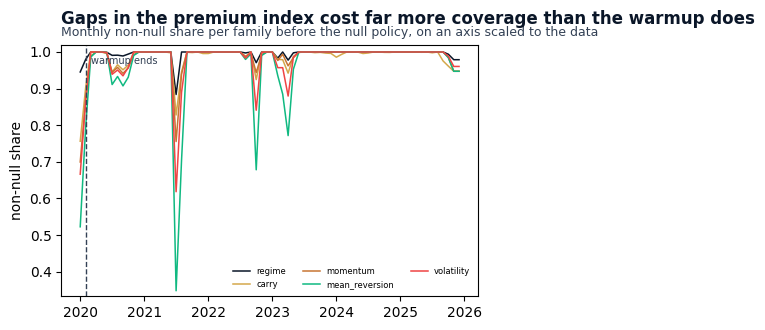

In [18]:
plot_coverage_through_time(
    family_coverage(
        trailing, {c: f for c, f in assignment.items() if c in SYMBOL_COLS}, every="1mo"
    ),
    warmup_boundary=features["timestamp"].min(),
    title="Gaps in the premium index cost far more coverage than the warmup does",
    subtitle="Monthly non-null share per family before the null policy, on an axis scaled to the data",
    alt=(
        "Line chart of non-null share against date for the five per-symbol families - carry, mean "
        "reversion, momentum, volatility and regime - on a y-axis running from about 0.35 to one. "
        "Every family sits at one for most months, with sharp isolated dips scattered from 2020 "
        "to 2023 and a shallow one at the end of 2025. A dashed line at the left edge marks the "
        "first settlement at which the contracts listed at the start have filled their windows; "
        "the dips through the rest of 2020 are later contracts listing and filling theirs. The "
        "deepest dips come after that and are missing premium-index observations: mid-2021, where "
        "mean reversion falls to about 0.35 and volatility to about 0.6, then late 2022 and early "
        "2023. Mean reversion falls furthest at every dip because its longest window is the "
        "thirty-day percentile, and the other four follow it down by progressively less in the "
        "same months."
    ),
)

### F4. The timing contract

The register's two timing columns, drawn. Each bar runs leftward from the decision timestamp by
that family's lookback, so its length is how far back the family reads. A family that waited for
data - one whose newest input is published after the decision it feeds - would show a gap between
the end of its bar and the decision line. None here does, because every observation any of these
families reads is published no later than the decision timestamp itself. That is the condition
that matters, and it is weaker than sharing a grid: the seven-day cash flow deliberately counts
the shortened two- and four-hour settlements from Section B, which fall between the eight-hour
decision times rather than on them, and those are knowable at the decision all the same.

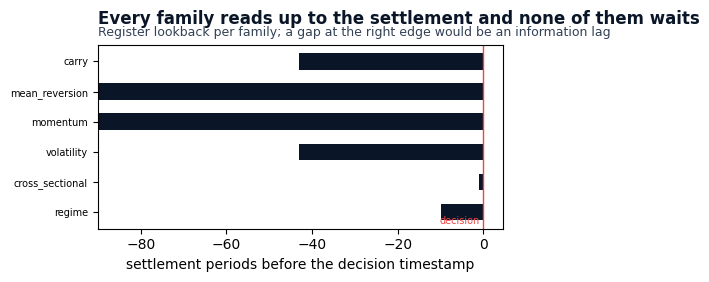

In [19]:
plot_timing_contract(
    FAMILIES,
    bar_unit="settlement periods",
    title="Every family reads up to the settlement and none of them waits",
    subtitle="Register lookback per family; a gap at the right edge would be an information lag",
    alt=(
        "Horizontal bars, one per feature family, each extending leftward from the decision line "
        "by that family's lookback: ninety settlement periods for momentum and mean reversion, "
        "forty-three for carry and volatility, ten for regime and one for the cross-sectional "
        "family. Every bar reaches the decision line, and there is no hatched lag segment on any "
        "of them."
    ),
)

The matrix carries **39 features** on **99,877 rows** across **19 perpetuals**, from
**2020-01-31** to **2025-12-31**, under content digest **873623a4af13b3fc**. Assembly discarded
**8,421** of the **108,298** settlement bars the panel starts with, and the **537** missing
premium-index observations in the input account for most of that rather than the warmup does.

In [20]:
print(
    f"{len(feature_cols)} features, {len(features):,} rows, {features['symbol'].n_unique()} perps"
)
print(f"{features['timestamp'].min()} to {features['timestamp'].max()}")

39 features, 99,877 rows, 19 perps
2020-01-31 08:00:00+00:00 to 2025-12-31 16:00:00+00:00


## F. What the features look like

Four properties decide whether this matrix can be used at all: the scale each feature arrives on,
whether the cross-section disagrees enough to rank on, how much of the set is one ordering under
several names, and how long a value lasts. All four are descriptive, and none of them reads a
label. Whether a feature predicts is a fold-aware question, and `05_evaluation` is where it is
asked.

### F2. Feature distributions

The percentile panel is a comb rather than the flat block a percentile usually draws, and that is
the cross-section showing through: nineteen perpetuals admit at most nineteen distinct positions
per settlement, and the panel is unbalanced, so the values it can take change with breadth. It is
still comparable across dates, which is the property it was built for, but a model that expects a
continuous input is being handed something closer to an ordered category.

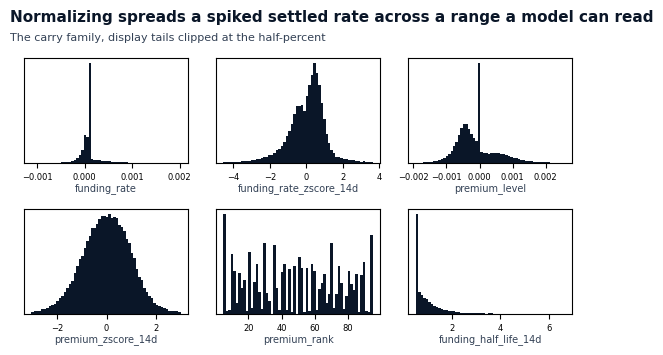

In [21]:
plot_feature_distributions(
    features,
    [
        "funding_rate",
        "funding_rate_zscore_14d",
        "premium_level",
        "premium_zscore_14d",
        "premium_rank",
        "funding_half_life_14d",
    ],
    title="Normalizing spreads a spiked settled rate across a range a model can read",
    subtitle="The carry family, display tails clipped at the half-percent",
    alt=(
        "Six histograms in two rows. The raw funding rate and the premium level are both a narrow "
        "spike at zero with thin tails either side, and almost no usable spread. Their trailing "
        "z-scores are broad: the funding z-score peaks just above zero and trails off to the left "
        "to about minus four, the premium z-score is close to symmetric between minus three and "
        "three. The cross-sectional percentile is not smooth but a comb of isolated bars spread "
        "evenly across the range. The half-life is concentrated at the short end, with a tall bar "
        "at the lower clip and a body that thins out over the first few settlements."
    ),
)

### F3. Cross-sectional dispersion through time

A cross-sectional strategy needs the cross-section to disagree. On a settlement where the band
narrows to nothing there is nothing to rank, whatever the average level of funding that day.

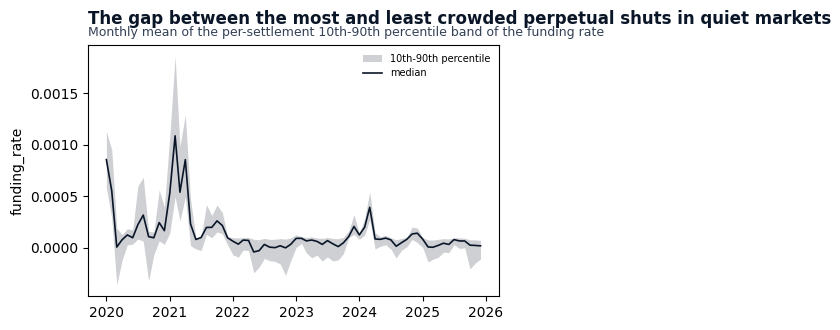

In [22]:
plot_cross_sectional_dispersion(
    features,
    "funding_rate",
    every="1mo",
    title="The gap between the most and least crowded perpetual shuts in quiet markets",
    subtitle="Monthly mean of the per-settlement 10th-90th percentile band of the funding rate",
    alt=(
        "Shaded band of the 10th to 90th percentile of the realized funding rate per settlement, "
        "averaged by month, with the median drawn through it. The band is widest through 2020 and "
        "2021, peaking sharply in the first quarter of 2021, then narrows to close to nothing "
        "from 2022 onward with only a brief reopening in early 2024. The median tracks the band "
        "and sits a little above zero for almost the whole sample."
    ),
)

### F5. Redundancy structure

Two features can be built from different quantities and still move together closely enough that
a model has little to gain from carrying both. This screens for that. Every feature is ranked
over the whole panel - all contracts, all settlements pooled - and the ranks are correlated, so
the distance $1 - |\rho_s|$ is small for a pair that rises and falls together across the sample.
The absolute value is what makes a feature and its negation land in the same group. The cut is
drawn at the correlation the configuration calls redundant, and the merges to the right of it,
at smaller distances, are the ones that exceed it.

Two limits are worth carrying forward, because a dendrogram invites more confidence than this
one has earned. A pooled correlation is not the cross-sectional ordering a long-short strategy
acts on: two features can track each other over the sample and still rank the universe
differently at a given settlement. And a correlation at the cut is a strong association, not
collinearity - a linear model can still estimate both coefficients, less precisely. So this is
an exploratory screen for what is worth investigating together, and picking one representative
from each group is a fold-aware decision `05_evaluation` makes against the labels.

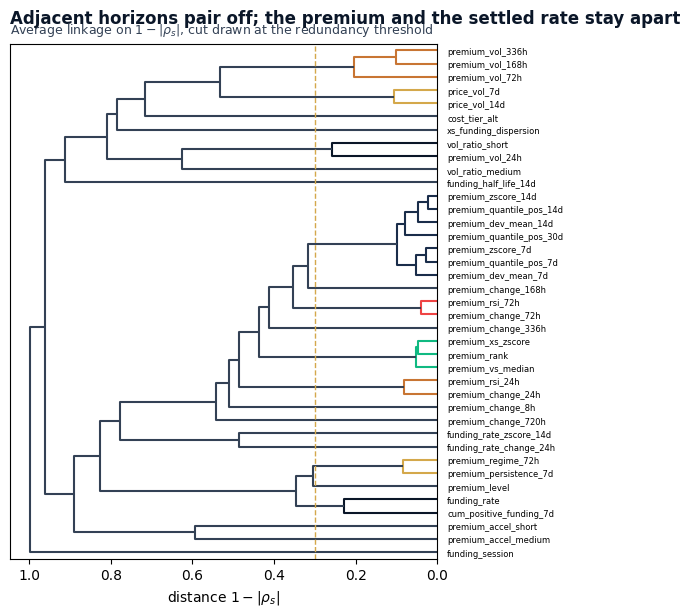

In [23]:
clusters = plot_redundancy_clusters(
    features,
    feature_cols,
    cut=REDUNDANCY_CUT,
    title="Adjacent horizons pair off; the premium and the settled rate stay apart",
    subtitle=r"Average linkage on $1 - |\rho_s|$, cut drawn at the redundancy threshold",
    alt=(
        "Dendrogram of all 39 features. The cut leaves 23 clusters, nine of which hold more than "
        "one feature. The largest is the normalized premium block, seven columns joined above the "
        "cut: both z-scores, all three percentile positions, and both deviations from a trailing "
        "mean. Two clusters hold three features each - the three premium volatility windows, and "
        "a cross-sectional group of the premium rank, the premium against the cross-sectional "
        "median, and the cross-sectional z-score. The other six are pairs: the realized funding "
        "rate with its seven-day cash flow; each oscillator with the premium change over its own "
        "window, once at one day and once at three; the regime indicator with premium "
        "persistence; the one-day premium volatility with the short volatility ratio; and the two "
        "price volatility windows. The remaining fourteen features stand alone and merge only "
        "near the root, among them the medium volatility ratio, the funding dispersion, the "
        "session marker and the premium level."
    ),
)

### F6. Persistence and rank stability

The autocorrelation on the left is of the feature, not of any return, so what it measures is how
long a value lasts rather than how well it works. It is estimated per perpetual on pairs of
settlements exactly one
lag apart and summarized by the median over perpetuals, with a bootstrap interval: a correlation
pooled over every symbol-settlement pair would read high whenever symbols sit at different
levels, whether or not any one of them persists. The right-hand panel asks the same question of
the ordering rather than the level, across consecutive rebalances - which here are consecutive
settlements, because that is the cadence this case study trades at.

Two readings are worth taking from it. The trailing volatility and the settled rate keep most of
their ordering from one settlement to the next; the normalized premium features keep very little
of theirs. That is a measurement of decay and nothing more - how fast a feature's value and its
ordering change, with no label anywhere in it. It is the earliest warning of turnover a feature
set can give: a ranking that is gone by the next rebalance would name a different set of
positions each time it is read. Whether it does is not settled here, because what a strategy
actually trades depends on how the ranking is mapped to positions, how many names are held, how
they are weighted, and the minimum weight change and trade size the configuration sets before a
rebalance happens at all. The backtest stages measure realized turnover under those rules; this
figure says which features would drive it. Whether any of them predicts, at this horizon or a
longer one, is a question `05_evaluation` asks against the labels, and this figure does not
answer it in either direction.

The second reading is that the oscillator turns negative at a lag equal to its own window, which
is what a bounded average of a fixed number of differences does when the differences themselves
carry no memory: it is measuring its own window rather than the market's.

The right-hand panel needs the list of rebalance times to correlate one against the next. It
indexes them through a Python dictionary, which carries microsecond precision, while this matrix
is stamped to the millisecond, so the copy handed to the figure is cast to match. The emitted
matrix keeps its own precision.

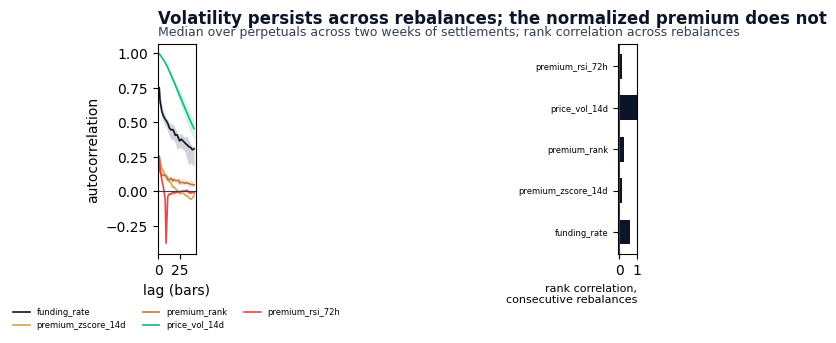

In [24]:
persistence_frame = features.with_columns(pl.col("timestamp").cast(pl.Datetime("us", "UTC")))
DECISION_DATES = persistence_frame["timestamp"].unique().sort().to_list()

plot_persistence(
    persistence_frame,
    ["funding_rate", "premium_zscore_14d", "premium_rank", "price_vol_14d", "premium_rsi_72h"],
    entity="symbol",
    max_lag=W["premium_zscore"]["14d"],
    decision_dates=DECISION_DATES,
    title="Volatility persists across rebalances; the normalized premium does not",
    subtitle="Median over perpetuals across two weeks of settlements; rank correlation across rebalances",
    alt=(
        "Two panels. On the left, autocorrelation against lag. The two-week price volatility "
        "starts at one and decays slowly to about 0.45 at the longest lag. The realized funding "
        "rate starts near 0.75 and falls to about 0.25. The premium z-score and the "
        "cross-sectional percentile both start near 0.25 and are at zero within about twenty "
        "settlements. The oscillator falls fastest, crossing zero and reaching about minus 0.35 "
        "at a lag equal to its own window before returning to zero. Bootstrap ribbons are narrow "
        "throughout. On the right, the rank correlation between consecutive rebalances orders "
        "them the same way: price volatility at one, the funding rate around 0.6, the percentile "
        "around 0.25, and the z-score and the oscillator both near 0.15."
    ),
)

Read together, the four figures describe a matrix that is on usable scales, carries a lot of
repetition, and turns over fast. The cross-section disagrees except in the quietest stretches,
where there is little to rank; the **39** columns fall into **23** groups once features that
move together over the sample are gathered; and only the trailing volatility and the raw settled
rate keep their ordering from one settlement to the next, while the normalized premium features
turn over almost completely. None of that is a statement about predictive content, which no
figure here measures.

## G. Emit

The matrix is written to `features/financial.parquet`, and everything downstream reads it from
there. [`04_model_based_features`](04_model_based_features.ipynb) opens the file directly, joins
it to the primary label, and fits the volatility and regime features that sit on top of it, fold
by fold. [`05_evaluation`](05_evaluation.ipynb) opens it directly too, and screens every column
in it for information content. The model-fitting notebooks from `06_linear` onward reach it
through the shared loader in `utils.modeling`, which assembles this file, the model-based
features and the labels into one training frame.

Beside the parquet goes a **digest sidecar**, a small JSON file recording what was written: a
short hash of the values themselves, the row count, the key columns, and the same hash taken over
each input the matrix was built from. Its point is that the hash is computed over content rather
than file bytes, so rewriting the file in a different row order leaves it alone while changing a
single feature value moves it. That is the check the experiment registry cannot make on its own:
the registry records the *name* of a feature set, so a corrected feature changes every number
downstream without changing anything the registry stores, and the sidecar is what makes the
change visible.

In [25]:
FEATURES_DIR.mkdir(parents=True, exist_ok=True)
record = write_artifact(
    features,
    FEATURES_DIR / "financial.parquet",
    keys=["symbol", "timestamp"],
    written_by="case_studies/crypto_perps_funding/03_financial_features.py",
    inputs={
        "load_crypto_perps": value_digest(prices),
        "load_funding_rates": value_digest(funding),
    },
)
print(f"Wrote case_studies/crypto_perps_funding/features/financial.parquet, {record['digest']}")
print(f"{len(set(clusters.values()))} redundancy clusters at the cut drawn in F5")

Wrote case_studies/crypto_perps_funding/features/financial.parquet, 873623a4af13b3fc
23 redundancy clusters at the cut drawn in F5


## Key takeaways

- **Move the clock before you build anything.** A provider stamps a bar with the time it opened;
  a feature has to be stamped with the time it became knowable. Every shift, join and window
  here inherits that one decision, and `02_labels` makes the same one.
- **State the timing contract before writing the feature.** The register fixes each family's
  lookback and lag in the configuration, and the warmup assertion and the timing figure both read
  those numbers rather than re-deriving them from the code.
- **Establish the holdout boundary by construction, not by inspection.** Rebuilding the whole
  panel with the holdout withheld and comparing every column catches a transform fitted across
  the sample without anyone having to know in advance which transform to look at.
- **Normalize what the exchange distorts.** The settled rate is capped and spiked; its trailing
  z-score and its position within the settlement stay comparable across symbols and regimes, and
  F6 is where that difference shows up as persistence.

### Known limitations

- The universe is a fixed nineteen-symbol research panel rather than a point-in-time liquidity
  ranking, a selection bias `01_feasibility_analysis` documents and this notebook inherits.
- The fee tier is a fixed list in the configuration. A perpetual that changed tier during the
  sample carries the wrong one for part of it.
- The funding rate is knowable at the settlement instant and not before it, so a strategy that
  wanted to act ahead of a settlement would have to use the premium-index features alone.
- Every feature here is a rule written in advance. `04_model_based_features` adds the features
  that are themselves model outputs, where the rule is estimated from the data.